# Matching-sex — Statistical Comparison of Matched Diagnostic Groups

Loads matched pair CSVs produced by `Matching_sex.R` and performs:
- Outlier removal (IQR-based) with sensitivity analysis across 4 thresholds
- Cliff's Delta effect size between diagnostic groups
- Permutation test (two-sided) for mean difference
- Brain Age Gap (BAG) boxplots per diagnostic group


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def remove_outliers_iqr(df, col, iqr_k=1.5):
    """Remove rows where col falls outside [Q1 - k*IQR, Q3 + k*IQR]."""
    s   = pd.to_numeric(df[col], errors="coerce")
    q1  = s.quantile(0.25)
    q3  = s.quantile(0.75)
    iqr = q3 - q1

    # BUG FIXED: low/high were swapped and OR was used instead of AND
    low  = q1 - iqr_k * iqr
    high = q3 + iqr_k * iqr

    return df.loc[(s >= low) & (s <= high)].copy()


def cliffs_delta(x, y):
    """Cliff's Delta effect size: (n_greater - n_less) / (nx * ny)."""
    x  = pd.to_numeric(pd.Series(x).dropna(), errors="coerce").dropna().values
    y  = pd.to_numeric(pd.Series(y).dropna(), errors="coerce").dropna().values
    nx, ny = len(x), len(y)
    if nx == 0 or ny == 0:
        return np.nan
    diffs     = x[:, None] - y[None, :]
    n_greater = np.sum(diffs > 0)
    n_less    = np.sum(diffs < 0)
    # BUG FIXED: denominator was (nx + ny); correct formula uses (nx * ny)
    return float((n_greater - n_less) / (nx * ny))


def permutation_pvalue(x, y, n_perm=10_000, seed=42):
    """Two-sided permutation test for difference of means."""
    rng = np.random.default_rng(seed)
    x   = np.array(pd.Series(x).dropna())
    y   = np.array(pd.Series(y).dropna())
    if len(x) == 0 or len(y) == 0:
        return np.nan
    obs_diff = np.abs(np.mean(x) - np.mean(y))   # BUG FIXED: must be absolute
    combined = np.concatenate([x, y])
    nx       = len(x)
    count    = sum(
        np.abs(np.mean(combined[:nx]) - np.mean(combined[nx:])) >= obs_diff
        for _ in (rng.shuffle(combined) or range(n_perm))
    )
    return count / n_perm


def chunk_list(lst, n):
    """Split list into consecutive chunks of size n."""
    # BUG FIXED: range stopped early (len - n); now covers full list
    for i in range(0, len(lst), n):
        yield lst[i:i + n]


def plot_gap_by_diagnosis_clean_wrap(
    df,
    gap_col,
    diagnosis_list,
    thresholds=(0.1, 0.5, 1.0, 1.5),
    per_line=3,
    title_fontsize=8,
    n_perm=10_000
):
    """
    For each IQR threshold: remove outliers, compute Cliff's Delta and
    permutation p-values for all pairwise comparisons, then draw boxplots.

    Returns: fig, axes, results_df
    """
    group_data_orig = {
        diag: df[df["Diagnosis"] == diag][[gap_col]].assign(Origen=diag)
        for diag in diagnosis_list
    }

    all_pairs = [
        (diagnosis_list[i], diagnosis_list[j])
        for i in range(len(diagnosis_list))
        for j in range(i + 1, len(diagnosis_list))
    ]
    cn_pairs    = [(a, b) for (a, b) in all_pairs if a == "CN"]
    other_pairs = [p for p in all_pairs if p not in cn_pairs]

    results_table = []
    fig, axes     = plt.subplots(2, 2, figsize=(7.0, 8.0), sharey=True)
    axes          = axes.flatten()

    for ax, iqr_k in zip(axes, thresholds):

        group_data_clean = {
            diag: remove_outliers_iqr(group_data_orig[diag], gap_col, iqr_k)
            for diag in diagnosis_list
        }

        lines = []
        for pairs, use_clean_cd in [(cn_pairs, True), (other_pairs, False)]:
            for a, b in pairs:
                x_clean = group_data_clean[a][gap_col]
                y_clean = group_data_clean[b][gap_col]
                x_orig  = group_data_orig[a][gap_col]
                y_orig  = group_data_orig[b][gap_col]

                # Cliff's Delta on cleaned data for consistency
                dval = cliffs_delta(x_clean, y_clean)
                pval = permutation_pvalue(x_clean, y_clean, n_perm=n_perm)

                lines.append(f"{a}-{b}: {dval:.3f}")
                results_table.append([iqr_k, a, b, dval, pval])

        wrapped     = [" | ".join(chunk) for chunk in chunk_list(lines, per_line)]
        title_parts = [f"IQR={iqr_k}"] + wrapped
        ax.set_title("\n".join(title_parts), fontsize=title_fontsize)

        combined = pd.concat(
            [group_data_clean[d] for d in diagnosis_list], ignore_index=True
        )
        sns.boxplot(
            data=combined, x="Origen", y=gap_col,
            order=diagnosis_list[::-1], ax=ax
        )
        ax.axhline(0, color="gray", linestyle="--", linewidth=1)
        ax.set_xlabel(""); ax.set_ylabel(gap_col)

    plt.tight_layout()

    results_df = (
        pd.DataFrame(results_table,
                     columns=["IQR_k", "Group1", "Group2", "CliffsDelta", "p_value"])
        .sort_values("p_value")
        .reset_index(drop=True)
    )
    return fig, axes, results_df


## Load matched CSV files

In [4]:
files = [
    'matched_AD_vs_DCL.csv',
    'matched_AD_vs_FTD-L.csv',
    'matched_AD_vs_FTD.csv',
    'matched_CN_vs_AD.csv',
    'matched_CN_vs_DCL.csv',
    'matched_CN_vs_FTD-L.csv',
    'matched_CN_vs_FTD.csv',
    'matched_FTD-L_vs_DCL.csv',
    'matched_FTD_vs_DCL.csv',
    'matched_FTD_vs_FTD-L.csv',
]

dfs = [pd.read_csv('C:\\Users\\eguen\\Documents\\Ernesto\\Articulos\\RedLat\\Files\\Data\\' + f) for f in files]
df_all = pd.concat(dfs, ignore_index=True)

print(f"Total rows loaded : {len(df_all)}")
print(f"Columns           : {list(df_all.columns)}")
print(f"Diagnoses found   : {df_all['Diagnosis'].unique()}")


Total rows loaded : 3800
Columns           : ['...1', 'ID', 'Sex_1F_2M', 'Education', 'Age', 'Diagnosis', 'BAG', 'diagnosis_binary', 'distance', 'weights', 'subclass']
Diagnoses found   : <StringArray>
['AD', 'DCL', 'FTD-L', 'FTD', 'CN']
Length: 5, dtype: str


## BAG comparison across diagnostic groups

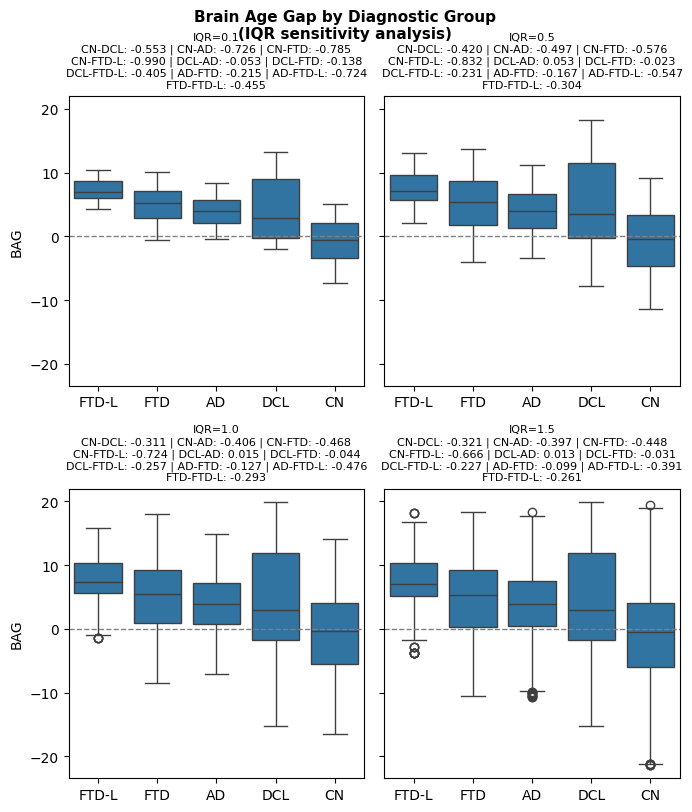

In [5]:
diagnosis_list = ["CN", "DCL", "AD", "FTD", "FTD-L"]

fig, axes, results_df = plot_gap_by_diagnosis_clean_wrap(
    df_all,
    gap_col        = "BAG",
    diagnosis_list = diagnosis_list,
    n_perm         = 10_000
)

plt.suptitle("Brain Age Gap by Diagnostic Group\n(IQR sensitivity analysis)",
             fontsize=11, fontweight="bold", y=1.01)
plt.show()


## Results table — Cliff's Delta & permutation p-values

In [6]:
print(results_df.to_string(index=False))

 IQR_k Group1 Group2  CliffsDelta  p_value
   0.1     CN    DCL    -0.553420      0.0
   0.1     CN     AD    -0.726453      0.0
   0.1     CN    FTD    -0.785093      0.0
   0.1     CN  FTD-L    -0.990038      0.0
   0.1    DCL    FTD    -0.138480      0.0
   0.1    DCL  FTD-L    -0.404588      0.0
   0.1     AD    FTD    -0.215014      0.0
   0.1     AD  FTD-L    -0.723529      0.0
   0.5     CN    FTD    -0.575867      0.0
   0.1    FTD  FTD-L    -0.455137      0.0
   0.5     CN    DCL    -0.419854      0.0
   0.5     CN     AD    -0.497058      0.0
   0.5    DCL     AD     0.053401      0.0
   0.5     CN  FTD-L    -0.832436      0.0
   0.5     AD    FTD    -0.166691      0.0
   0.5    DCL  FTD-L    -0.230965      0.0
   1.0    DCL     AD     0.014706      0.0
   1.0    DCL    FTD    -0.043950      0.0
   0.5     AD  FTD-L    -0.547173      0.0
   0.5    FTD  FTD-L    -0.303890      0.0
   1.0     CN    DCL    -0.310612      0.0
   1.0     CN     AD    -0.406191      0.0
   1.0     